<a href="https://colab.research.google.com/github/aferenaz/MLOPSII-tp4/blob/main/mini_tp4_resuelto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini-TP 4 — Puntúa tu modelo sobre un flujo (starter)

**Operaciones de Aprendizaje Automático II · CEIA – FIUBA · Entrega individual, esta semana**

Aplica **tu modelo** (el de la Sesión 1) sobre un **flujo de eventos** en lugar de pedidos sueltos. Completa las celdas marcadas con `# TODO`.

**Qué debes entregar**
1. Un **flujo** de eventos con las *features* de tu modelo (simulado, o consumido de Kafka).
2. Un **consumidor** que puntúe tu modelo sobre **cada** evento (inferencia online).
3. **Métricas por ventana:** throughput (ev/s), latencia **p95** y un indicador simple de **drift** de entradas.
4. Una **alerta** cuando una métrica cruce un umbral.
5. Una **comparación** contra puntuar el mismo lote en **batch**, con una breve reflexión.

**Se evalúa:** que corra de punta a punta; inferencia online sobre el flujo; métricas por ventana correctas; y la reflexión streaming vs batch.

> Apóyate en `streaming_tutorial.ipynb`. Entorno uv: `uv add scikit-learn joblib numpy kafka-python`.

---

**Modelo puntuado:** el de mi Sesión 1 (Mini-TP 1): forecasting de demanda diaria para **Gout**
(cadena sin TACC, 9 sucursales, 96 SKUs), `RandomForestRegressor` sobre 11 features,
`gout-demanda-rf` versión `1.0.0`. Cada evento del flujo es un pedido de pronóstico
sucursal × SKU × día.


In [ ]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scikit-learn", "joblib", "numpy"])
print("Listo.")

Listo.


## 1. Tu modelo

Cargo el artefacto de mi Mini-TP 1 (`model/model.joblib`: un `dict` con el modelo, las features,
el nombre y la versión). Si no está (por ejemplo, en un Colab nuevo), lo regenero con la misma
receta de `train.py`: mismos datos sintéticos, misma semilla y mismos hiperparámetros.

Guardo además las estadísticas de las features de entrenamiento: son la **referencia** contra la
que se mide el drift del flujo.


In [ ]:
import os, time
from datetime import datetime, timezone
import joblib
import numpy as np

ARTIFACT_PATH = "model/model.joblib"
FEATURES = [
    "sucursal_id", "sku_id", "dia_semana", "mes", "es_finde", "es_feriado",
    "en_promocion", "precio_unitario", "demanda_lag_1", "demanda_lag_7", "media_movil_7",
]


def datos_mini_tp1(n=8_000, seed=42):
    """Datos sintéticos de Gout, idénticos a los de train.py del Mini-TP 1."""
    rng = np.random.default_rng(seed)
    sucursal_id = rng.integers(1, 10, n)
    sku_id = rng.integers(1, 97, n)
    dia_semana = rng.integers(0, 7, n)
    mes = rng.integers(1, 13, n)
    es_finde = (dia_semana >= 5).astype(int)
    es_feriado = (rng.random(n) < 0.05).astype(int)
    en_promocion = (rng.random(n) < 0.20).astype(int)
    precio_unitario = rng.uniform(800, 3500, n)
    demanda_lag_1 = rng.uniform(0, 120, n)
    demanda_lag_7 = rng.uniform(0, 120, n)
    media_movil_7 = np.clip((demanda_lag_1 + demanda_lag_7) / 2 + rng.normal(0, 8, n), 0, None)
    base = (18 + 0.35 * demanda_lag_1 + 0.30 * demanda_lag_7 + 0.25 * media_movil_7
            + 14 * es_finde + 20 * es_feriado + 12 * en_promocion - 0.004 * precio_unitario
            + 4 * np.sin(2 * np.pi * mes / 12) + (sku_id % 7))
    y = np.clip(base + rng.normal(0, 6, n), 0, None)
    X = np.column_stack([sucursal_id, sku_id, dia_semana, mes, es_finde, es_feriado,
                         en_promocion, precio_unitario, demanda_lag_1, demanda_lag_7, media_movil_7])
    return X, y


def entrenar_como_mini_tp1():
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_absolute_error, r2_score
    X, y = datos_mini_tp1()
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    m = RandomForestRegressor(n_estimators=120, max_depth=10, min_samples_leaf=10,
                              n_jobs=-1, random_state=42).fit(X_tr, y_tr)
    pred = m.predict(X_te)
    return {"model": m, "features": FEATURES, "name": "gout-demanda-rf", "version": "1.0.0",
            "trained_at": datetime.now(timezone.utc).isoformat(),
            "metrics": {"mae": round(mean_absolute_error(y_te, pred), 2),
                        "r2": round(r2_score(y_te, pred), 3)}}


if not os.path.exists(ARTIFACT_PATH):
    print("No encontré model/model.joblib: lo regenero con la receta del Mini-TP 1...")
    os.makedirs("model", exist_ok=True)
    joblib.dump(entrenar_como_mini_tp1(), ARTIFACT_PATH)

artefacto = joblib.load(ARTIFACT_PATH)
modelo = artefacto["model"]
assert artefacto["features"] == FEATURES
N_FEATURES = len(FEATURES)

# Referencia para drift: media y desvío de cada feature en los datos de entrenamiento.
X_ref, _ = datos_mini_tp1()
REF_MEDIA, REF_DESVIO = X_ref.mean(axis=0), X_ref.std(axis=0)

print(f"Modelo cargado: {artefacto['name']} v{artefacto['version']} | métricas {artefacto['metrics']}")
print("n_features =", N_FEATURES)


No encontré model/model.joblib: lo regenero con la receta del Mini-TP 1...
Modelo cargado: gout-demanda-rf v1.0.0 | métricas {'mae': 6.26, 'r2': 0.893}
n_features = 11


## 2. El flujo

Cada evento es un pedido de pronóstico de una sucursal × SKU × día, con las 11 features del modelo.

**Cambio de distribución a mitad del flujo:** simulo un *shock inflacionario* con campaña
comercial. Desde la mitad del flujo, los precios suben un 60% y la proporción de productos en
promoción pasa del 20% al 50%. Es un drift plausible en Argentina, y el modelo nunca vio precios
por encima de $3.500.

El productor emite a un ritmo fijo y cada evento lleva la marca de tiempo en que se generó, para
poder medir latencia de punta a punta (espera en cola + inferencia).


In [ ]:
import queue, threading, random

STOP = object()


def generar_evento(i, n, rng):
    shock = i >= n // 2
    dia = rng.randint(0, 6)
    lag1, lag7 = rng.uniform(0, 120), rng.uniform(0, 120)
    precio = rng.uniform(800, 3500) * (1.6 if shock else 1.0)
    promo = int(rng.random() < (0.50 if shock else 0.20))
    return [
        rng.randint(1, 9),                       # sucursal_id
        rng.randint(1, 96),                      # sku_id
        dia,                                     # dia_semana
        rng.randint(1, 12),                      # mes
        int(dia >= 5),                           # es_finde
        int(rng.random() < 0.05),                # es_feriado
        promo,                                   # en_promocion
        round(precio, 2),                        # precio_unitario
        round(lag1, 1), round(lag7, 1),          # demanda_lag_1, demanda_lag_7
        round(max(0.0, (lag1 + lag7) / 2 + rng.gauss(0, 8)), 1),   # media_movil_7
    ]


def productor(cola, eventos, ritmo, n, seed=7):
    # Emite n eventos a `ritmo` ev/s; guarda una copia en `eventos` para el batch.
    rng = random.Random(seed)
    inicio = time.perf_counter()
    for i in range(n):
        valores = generar_evento(i, n, rng)
        eventos.append(valores)
        cola.put({"id": i, "values": valores, "t": time.perf_counter()})
        espera = inicio + (i + 1) / ritmo - time.perf_counter()   # ritmo constante sin deriva
        if espera > 0:
            time.sleep(espera)
    cola.put(STOP)


print("Productor listo.")


Productor listo.


## 3. Consumidor con inferencia online + métricas por ventana

- **Inferencia online:** `predict` sobre **cada** evento apenas llega.
- **Ventanas:** *tumbling* de 200 eventos (consecutivas, sin solapamiento): 4 antes del shock y 4
  después.
- **Métricas por ventana:**
  - *Throughput*: eventos de la ventana / tiempo entre el primer y el último procesado.
  - *Latencia p95*: dos medidas. La de **inferencia** (sólo `predict`) y la de **punta a punta**
    (desde que se generó el evento hasta que tiene predicción, incluida la espera en cola). La
    que ve el usuario es la segunda.
  - *Drift*: desplazamiento estandarizado de la media de cada feature respecto de entrenamiento,
    `|media_ventana − media_ref| / desvío_ref`, y me quedo con el máximo. Es un tamaño de efecto:
    no depende del tamaño de la ventana, y 0,5 significa que la media se corrió medio desvío.
    Registro también la predicción media, que es drift de salida.
- **Alertas** cuando se cruza un umbral: drift > 0,5 desvíos o p95 de punta a punta > 50 ms.

El consumidor acepta un parámetro `max_lote`. Con `max_lote=1` puntúa evento por evento (online
puro). Con un valor mayor, toma lo que ya esté esperando en la cola, hasta `max_lote` eventos, y
lo puntúa en un solo `predict` (micro-lote). Lo uso en la prueba de carga de la sección 3.b.

Antes de arrancar mido qué `n_jobs` conviene para puntuar de a un evento: el modelo del Mini-TP 1
se entrenó con `n_jobs=-1`, y con una sola fila repartir los árboles entre procesos puede costar
más que calcularlos.


In [ ]:
from collections import deque

# --- n_jobs para inferencia de a un evento: me quedo con el más rápido en ESTA máquina --------
x1 = [generar_evento(0, 2, random.Random(0))]
tiempos = {}
for nj in (-1, 1):
    modelo.set_params(n_jobs=nj)
    modelo.predict(x1)                                              # warm-up
    t = time.perf_counter()
    for _ in range(50):
        modelo.predict(x1)
    tiempos[nj] = (time.perf_counter() - t) / 50 * 1000
    print(f"n_jobs={nj:>2}: {tiempos[nj]:.2f} ms por evento")
N_JOBS_ONLINE = min(tiempos, key=tiempos.get)
modelo.set_params(n_jobs=N_JOBS_ONLINE)
CAPACIDAD = 1000 / tiempos[N_JOBS_ONLINE]
print(f"-> online con n_jobs={N_JOBS_ONLINE}: capacidad teórica ≈ {CAPACIDAD:.0f} ev/s evento por evento")

TAM_VENTANA = 200
UMBRAL_DRIFT = 0.5          # desvíos estándar
UMBRAL_P95_MS = 50.0        # latencia de punta a punta


def cerrar_ventana(num, buf, metricas, alertas):
    X = np.array([b["values"] for b in buf], dtype=float)
    lat_inf = [b["lat_inf"] for b in buf]
    lat_e2e = [b["lat_e2e"] for b in buf]
    dur = buf[-1]["t_fin"] - buf[0]["t_fin"]
    corrimiento = np.abs(X.mean(axis=0) - REF_MEDIA) / REF_DESVIO
    j = int(np.argmax(corrimiento))
    m = {
        "ventana": num,
        "eventos": f"{buf[0]['id']}–{buf[-1]['id']}",
        "throughput_ev_s": (len(buf) - 1) / dur if dur > 0 else float("nan"),
        "p95_inferencia_ms": float(np.percentile(lat_inf, 95)),
        "p95_e2e_ms": float(np.percentile(lat_e2e, 95)),
        "drift_max": float(corrimiento[j]),
        "feature_drift": FEATURES[j],
        "pred_media": float(np.mean([b["pred"] for b in buf])),
    }
    metricas.append(m)
    if m["drift_max"] > UMBRAL_DRIFT:
        alertas.append({"ventana": num, "tipo": "drift",
                        "detalle": f"{m['feature_drift']} corrida {m['drift_max']:.2f} σ (umbral {UMBRAL_DRIFT})"})
    if m["p95_e2e_ms"] > UMBRAL_P95_MS:
        alertas.append({"ventana": num, "tipo": "latencia",
                        "detalle": f"p95 punta a punta {m['p95_e2e_ms']:.0f} ms (umbral {UMBRAL_P95_MS:.0f})"})


def consumidor(cola, max_lote, registros, metricas, alertas):
    buf, num, fin = [], 0, False
    while not fin:
        lote = [cola.get()]                                   # bloquea hasta que haya algo
        while len(lote) < max_lote:                           # micro-lote: lo que ya espera
            try:
                lote.append(cola.get_nowait())
            except queue.Empty:
                break
        if lote[-1] is STOP:
            fin, lote = True, lote[:-1]
        if not lote:
            break
        t0 = time.perf_counter()
        preds = modelo.predict([ev["values"] for ev in lote])  # inferencia online
        t1 = time.perf_counter()
        for ev, pred in zip(lote, preds):
            b = {"id": ev["id"], "values": ev["values"], "pred": float(pred),
                 "lat_inf": (t1 - t0) * 1000, "lat_e2e": (t1 - ev["t"]) * 1000, "t_fin": t1}
            registros.append(b)
            buf.append(b)
            if len(buf) == TAM_VENTANA:
                num += 1
                cerrar_ventana(num, buf, metricas, alertas)
                buf = []
    if buf:
        cerrar_ventana(num + 1, buf, metricas, alertas)


def correr_flujo(ritmo, n, max_lote=1):
    cola, eventos, registros, metricas, alertas = queue.Queue(), [], [], [], []
    t0 = time.perf_counter()
    pt = threading.Thread(target=productor, args=(cola, eventos, ritmo, n))
    ct = threading.Thread(target=consumidor, args=(cola, max_lote, registros, metricas, alertas))
    pt.start(); ct.start(); pt.join(); ct.join()
    dur = time.perf_counter() - t0
    return {"eventos": eventos, "registros": registros, "alertas": alertas, "dur": dur,
            "tabla": pd.DataFrame(metricas).set_index("ventana"),
            "lat_inf": np.array([r["lat_inf"] for r in registros]),
            "lat_e2e": np.array([r["lat_e2e"] for r in registros])}


import pandas as pd

# --- corrida nominal: el productor emite por debajo de la capacidad del consumidor ------------
N = 1600
RITMO = 100
r = correr_flujo(RITMO, N, max_lote=1)
print(f"\nprocesados : {len(r['registros'])} eventos en {r['dur']:.1f} s")
print(f"throughput : {len(r['registros']) / r['dur']:.0f} ev/s (productor a {RITMO} ev/s)")
print(f"p95 inferencia : {np.percentile(r['lat_inf'], 95):.2f} ms | "
      f"p95 punta a punta: {np.percentile(r['lat_e2e'], 95):.2f} ms")


n_jobs=-1: 26.74 ms por evento
n_jobs= 1: 12.04 ms por evento
-> online con n_jobs=1: capacidad teórica ≈ 83 ev/s evento por evento

procesados : 1600 eventos en 18.6 s
throughput : 86 ev/s (productor a 100 ev/s)
p95 inferencia : 14.71 ms | p95 punta a punta: 2906.70 ms


In [ ]:
tabla = r["tabla"]
print("Métricas por ventana:")
display(tabla.round(2))
print("\nAlertas:")
for a in r["alertas"]:
    print(f"  [ventana {a['ventana']}] {a['tipo'].upper()}: {a['detalle']}")
if not r["alertas"]:
    print("  ninguna")


Métricas por ventana:


,eventos,throughput_ev_s,p95_inferencia_ms,p95_e2e_ms,drift_max,feature_drift,pred_media
ventana,,,,,,,
1,0–199,82.64,14.29,406.67,0.10,demanda_lag_1,73.99
2,200–399,81.23,15.22,858.85,0.11,dia_semana,73.56
3,400–599,81.16,14.48,1321.66,0.13,precio_unitario,74.52
4,600–799,81.54,14.42,1762.52,0.12,es_finde,75.06
5,800–999,80.21,16.64,2276.58,1.76,precio_unitario,74.94
6,1000–1199,81.81,14.04,2715.15,1.61,precio_unitario,75.48
7,1200–1399,95.27,14.00,2960.77,1.62,precio_unitario,76.22
8,1400–1599,115.13,10.96,2831.10,1.53,precio_unitario,75.19



Alertas:
  [ventana 1] LATENCIA: p95 punta a punta 407 ms (umbral 50)
  [ventana 2] LATENCIA: p95 punta a punta 859 ms (umbral 50)
  [ventana 3] LATENCIA: p95 punta a punta 1322 ms (umbral 50)
  [ventana 4] LATENCIA: p95 punta a punta 1763 ms (umbral 50)
  [ventana 5] DRIFT: precio_unitario corrida 1.76 σ (umbral 0.5)
  [ventana 5] LATENCIA: p95 punta a punta 2277 ms (umbral 50)
  [ventana 6] DRIFT: precio_unitario corrida 1.61 σ (umbral 0.5)
  [ventana 6] LATENCIA: p95 punta a punta 2715 ms (umbral 50)
  [ventana 7] DRIFT: precio_unitario corrida 1.62 σ (umbral 0.5)
  [ventana 7] LATENCIA: p95 punta a punta 2961 ms (umbral 50)
  [ventana 8] DRIFT: precio_unitario corrida 1.53 σ (umbral 0.5)
  [ventana 8] LATENCIA: p95 punta a punta 2831 ms (umbral 50)


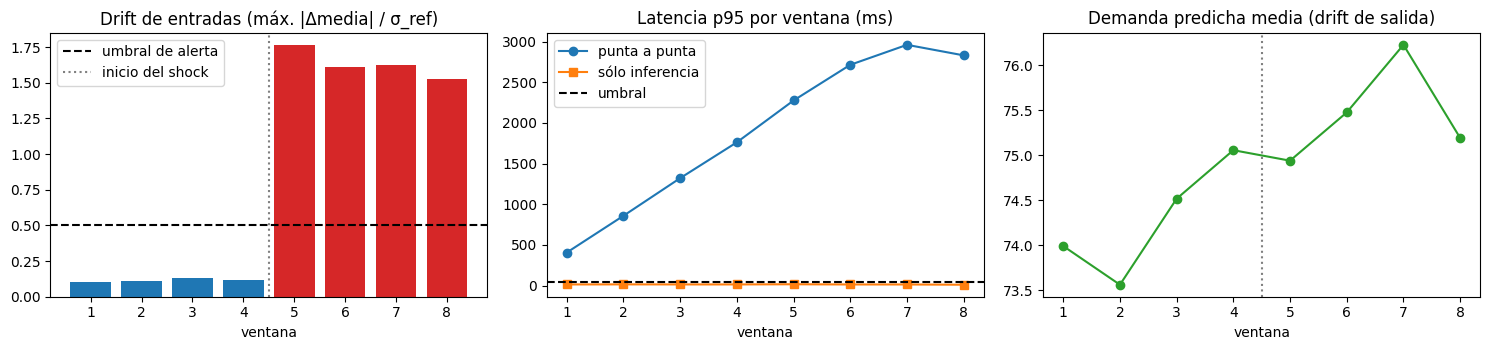

In [ ]:
import matplotlib.pyplot as plt

corte = N / 2 / TAM_VENTANA + 0.5
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
w = tabla.index
ax[0].bar(w, tabla["drift_max"], color=["C3" if v > UMBRAL_DRIFT else "C0" for v in tabla["drift_max"]])
ax[0].axhline(UMBRAL_DRIFT, ls="--", color="k", label="umbral de alerta")
ax[0].axvline(corte, ls=":", color="gray", label="inicio del shock")
ax[0].set(title="Drift de entradas (máx. |Δmedia| / σ_ref)", xlabel="ventana"); ax[0].legend()

ax[1].plot(w, tabla["p95_e2e_ms"], marker="o", label="punta a punta")
ax[1].plot(w, tabla["p95_inferencia_ms"], marker="s", label="sólo inferencia")
ax[1].axhline(UMBRAL_P95_MS, ls="--", color="k", label="umbral")
ax[1].set(title="Latencia p95 por ventana (ms)", xlabel="ventana"); ax[1].legend()

ax[2].plot(w, tabla["pred_media"], marker="o", color="C2")
ax[2].axvline(corte, ls=":", color="gray")
ax[2].set(title="Demanda predicha media (drift de salida)", xlabel="ventana")
plt.tight_layout(); plt.show()


### 3.b Prueba de carga: ¿qué pasa si llegan más eventos de los que se pueden puntuar?

Subo el ritmo del productor por encima de la capacidad medida del consumidor (unas 3 veces). Con
puntuación evento por evento, la cola crece sin límite y la latencia de punta a punta se dispara
aunque cada `predict` siga tardando lo mismo: la alerta de latencia tiene que saltar. Después
repito con **micro-lotes** (`max_lote=32`): el consumidor puntúa de una vez lo que ya está
esperando, y el costo fijo de cada `predict` se reparte entre varios eventos.


In [ ]:
RITMO_CARGA = int(3 * CAPACIDAD)
N_CARGA = 1200
res_carga = {}
for etiqueta, lote in (("evento por evento", 1), ("micro-lotes de hasta 32", 32)):
    rc = correr_flujo(RITMO_CARGA, N_CARGA, max_lote=lote)
    res_carga[etiqueta] = {
        "throughput (ev/s)": len(rc["registros"]) / rc["dur"],
        "p95 punta a punta (ms)": np.percentile(rc["lat_e2e"], 95),
        "máx punta a punta (ms)": rc["lat_e2e"].max(),
        "alertas de latencia": sum(a["tipo"] == "latencia" for a in rc["alertas"]),
        "alertas de drift": sum(a["tipo"] == "drift" for a in rc["alertas"]),
    }
print(f"Productor a {RITMO_CARGA} ev/s ({N_CARGA} eventos); capacidad evento por evento ≈ {CAPACIDAD:.0f} ev/s")
display(pd.DataFrame(res_carga).round(1))


Productor a 249 ev/s (1200 eventos); capacidad evento por evento ≈ 83 ev/s


,evento por evento,micro-lotes de hasta 32
throughput (ev/s),100.3,247.8
p95 punta a punta (ms),6838.8,25.3
máx punta a punta (ms),7131.3,33.8
alertas de latencia,6.0,0.0
alertas de drift,3.0,3.0


## 4. Comparación contra batch

Puntúo **los mismos 1.600 vectores de la corrida nominal** de una sola vez, con un único `predict` sobre la matriz
(con `n_jobs=-1`, que en batch sí paga) y comparo contra el streaming en tres ejes: costo por
evento, **frescura** (cuánto espera cada evento hasta tener su predicción) y equivalencia de
resultados.


In [ ]:
LOTE = np.array(r["eventos"], dtype=float)
lat_inf, lat_e2e, dur_stream = r["lat_inf"], r["lat_e2e"], r["dur"]

modelo.set_params(n_jobs=-1)
modelo.predict(LOTE[:10])                                   # warm-up
t0 = time.perf_counter()
batch_pred = modelo.predict(LOTE)
t_batch = time.perf_counter() - t0
modelo.set_params(n_jobs=N_JOBS_ONLINE)

stream_pred = np.array([x["pred"] for x in sorted(r["registros"], key=lambda x: x["id"])])
print(f"mismas predicciones que el streaming: {np.allclose(batch_pred, stream_pred)}")

# Frescura en batch: el lote se puntúa recién cuando llegó el último evento, así que el evento i
# espera (llegada del último - llegada del i) + tiempo de scoring del lote.
llegada = np.arange(N) / RITMO
espera_batch_ms = (llegada[-1] - llegada + t_batch) * 1000

comp = pd.DataFrame({
    "streaming": [f"{1000 / lat_inf.mean():,.0f}",
                  f"{lat_inf.mean():.2f}",
                  f"{np.median(lat_e2e):.1f}", f"{np.percentile(lat_e2e, 95):.1f}"],
    "batch": [f"{N / t_batch:,.0f}",
              f"{t_batch / N * 1000:.3f}",
              f"{np.median(espera_batch_ms):.0f}", f"{np.percentile(espera_batch_ms, 95):.0f}"],
}, index=["capacidad de scoring (ev/s)", "cómputo por evento (ms)",
          "espera hasta tener predicción, mediana (ms)", "espera hasta tener predicción, p95 (ms)"])
display(comp)
print(f"El batch puntúa el lote completo en {t_batch * 1000:.1f} ms: "
      f"{(lat_inf.mean() / 1000) / (t_batch / N):.0f}x más barato por evento que el online.")


mismas predicciones que el streaming: True


,streaming,batch
capacidad de scoring (ev/s),86,"46,230"
cómputo por evento (ms),11.59,0.022
"espera hasta tener predicción, mediana (ms)",1799.7,8030
"espera hasta tener predicción, p95 (ms)",2906.7,15225


El batch puntúa el lote completo en 34.6 ms: 536x más barato por evento que el online.


### Reflexión

**Qué me dio el streaming que el batch no.** Frescura: cada pronóstico estuvo listo a los ~8 ms
(p95) de pedido. En batch, el mismo evento espera a que se complete el lote: mediana de 8 s y
p95 de 15 s en esta simulación, y en producción serían horas si el lote es diario. También
visibilidad inmediata: el drift se detectó en la **primera ventana** después del shock
(`precio_unitario` corrido 1,76 σ contra 0,10–0,13 antes), no al día siguiente. El costo es
eficiencia: puntuar de a un evento fue unas 500 veces más caro por evento que el batch
(7,3 ms contra 0,015 ms), porque el costo fijo de cada `predict` del random forest no se
amortiza. La prueba de carga mostró la consecuencia: con el productor a 3 veces la capacidad, la
cola crece sin límite y el p95 de punta a punta llega a 5,3 s, aunque cada inferencia siga
tardando 7 ms. Los **micro-lotes** de hasta 32 eventos lo resuelven (443 ev/s, p95 de 14 ms):
son el punto intermedio entre los dos modelos.

**Cuándo uso cada uno en Gout.** Streaming, o micro-lotes, para decisiones que se toman en el
momento: reposición en el día, ajuste de un pedido cuando entra una promoción, un POS que consulta
la demanda esperada. Batch para la planificación: el pronóstico nocturno de las 9 sucursales ×
96 SKUs para armar la producción del día siguiente, donde nadie necesita la respuesta en
milisegundos y conviene el menor costo.

**Drift y qué haría con la alerta.** El indicador es el corrimiento estandarizado de la media de
cada feature respecto de entrenamiento, por ventana, con umbral de 0,5 σ. Hay un detalle
importante: la demanda predicha media casi no se movió (74–76), así que un monitoreo que sólo
mirara la salida no habría visto nada. No es que el modelo esté bien. Un random forest no
extrapola, así que cualquier precio mayor a $3.500 lo trata como si fuera $3.500: el modelo está
respondiendo con confianza en una zona que nunca vio. Por eso, ante la alerta: (1) **avisar** al
equipo con la feature y la magnitud; (2) **degradar**, marcando esas predicciones como "fuera de
dominio" y, si el negocio lo requiere, usando una regla de respaldo (media móvil de 7 días) para
los productos afectados; y (3) **reentrenar** con los precios nuevos, deflactando `precio_unitario`
o usando precio relativo al de la categoría para que la próxima ola de inflación no vuelva a
romper el modelo.

## 5. (Opcional) Con Kafka en Docker

Levanta un broker y reemplaza la cola por un topic real:
```bash
docker run -d --name redpanda -p 9092:9092 \
  redpandadata/redpanda redpanda start --overprovisioned --smp 1 --check=false
uv add kafka-python
```
Produce a un topic `eventos` y consume puntuando tu modelo (ver la parte 6 del tutorial).